In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:32798")
client

<Client: 'tcp://127.0.0.1:32798' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

In [4]:
ipass = 21
ds = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                          % ipass))
ds.coords["num_lines"] = ("num_lines", range(len(ds.num_lines)))
ds.coords["num_pixels"] = ("num_pixels", range(len(ds.num_pixels)))
if ipass == 21:
    reg = "PS"
    maskn = xr.DataArray(ds.latitude.where(ds.latitude<40.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    masks = xr.DataArray(dsns.latitude.where(dsns.latitude>10.).to_masked_array().mask,
                         dims=dsns.latitude.dims,
                         coords=dsns.latitude.coords
                        )
    
    dsns = dsns.where(~masks,drop=True)
elif ipass == 4 or ipass == 19:
    reg = "Kx"
    maskn = xr.DataArray(ds.latitude.where(ds.latitude<50.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    masks = xr.DataArray(dsns.latitude.where(dsns.latitude>20.).to_masked_array().mask,
                         dims=dsns.latitude.dims,
                         coords=dsns.latitude.coords
                        )
    
    dsns = dsns.where(~masks,drop=True)
ds21 = xr.open_zarr(op.join(ddir,
                            "tssh_swot1day/Pass%03d/"
                            % ipass)
                    + reg + "/ssh-total_rawgrid.zarr"
                   )
ds21

<xarray.Dataset> Size: 101MB
Dimensions:     (cycle_num: 105, num_lines: 1703, num_pixels: 69)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 5485 5486 5487 5488 ... 7185 7186 7187
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    pass_num    int64 8B ...
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 99MB dask.array<chunksize=(14, 426, 18), meta=np.ndarray>

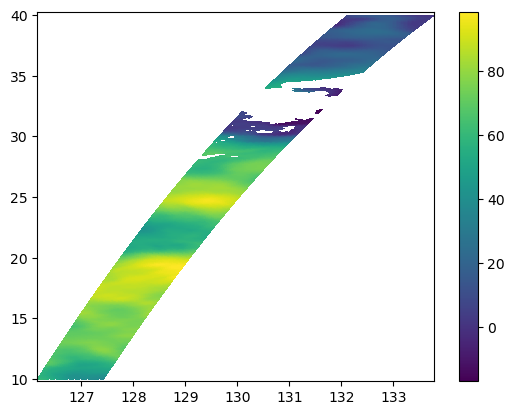

In [5]:
fig, ax = plt.subplots()
im = ax.pcolor(ds21.longitude, ds21.latitude,
          ds21.ssha.sel(cycle_num=533), 
          rasterized=True
         )
fig.colorbar(im)
plt.show()

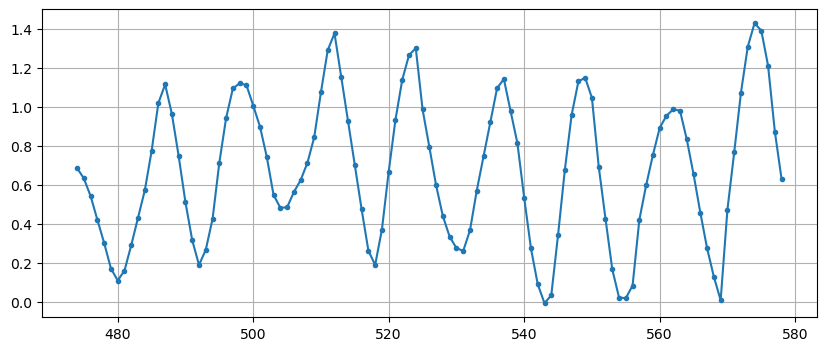

In [6]:
h_dropped = ds21.ssha.dropna("num_lines",how="all") * 1e-2

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(h_dropped.cycle_num, 
        h_dropped.mean(['num_lines','num_pixels'],skipna=True),
         '.-')
# ax.plot(h_dropped.cycle_num.isel(cycle_num=slice(-9,None)), 
#         h_dropped.isel(cycle_num=slice(-9,None)
#                       ).mean(['num_lines','num_pixels'],skipna=True
#                             )*1e2/9.81,
#          '.-')
ax.grid(True)

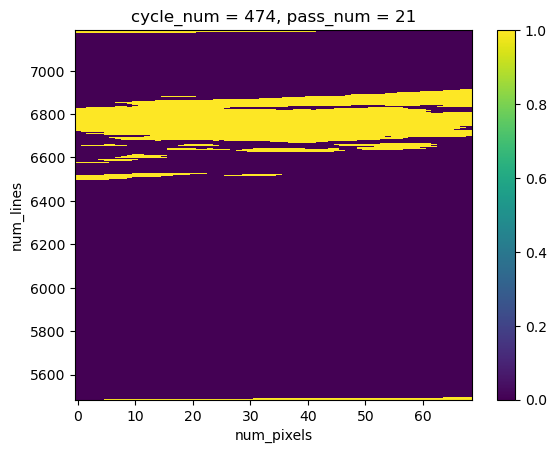

In [7]:
mm21 = xr.DataArray(ds21.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds21.ssha.isel(cycle_num=0).dims, 
                     coords=ds21.ssha.isel(cycle_num=0).coords
                    )
# mm21 = xr.DataArray(mask21.where(mask21<.5
#                               ).to_masked_array().mask,
#                    dims=dsns.tssh.isel(cycle_num=0).dims, 
#                    coords=dsns.tssh.isel(cycle_num=0).coords
#                   ).isel(num_pixels=slice(inp,-inp))
mm21.plot(rasterized=True)

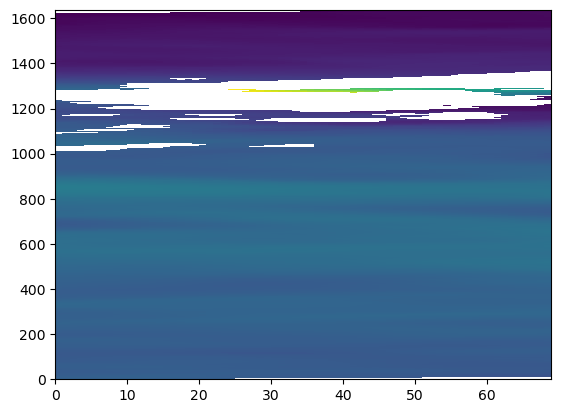

<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 1638, num_pixels: 69)> Size: 95MB
dask.array<mul, shape=(105, 1638, 69), dtype=float64, chunksize=(14, 425, 18), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 13kB 5485 5486 5487 5488 ... 7185 7186 7187
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 904kB dask.array<chunksize=(1638, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 904kB dask.array<chunksize=(1638, 69), meta=np.ndarray>
    pass_num    int64 8B ...

In [8]:
plt.pcolormesh(h_dropped.isel(cycle_num=10).data,rasterized=True)
plt.show()
h_dropped

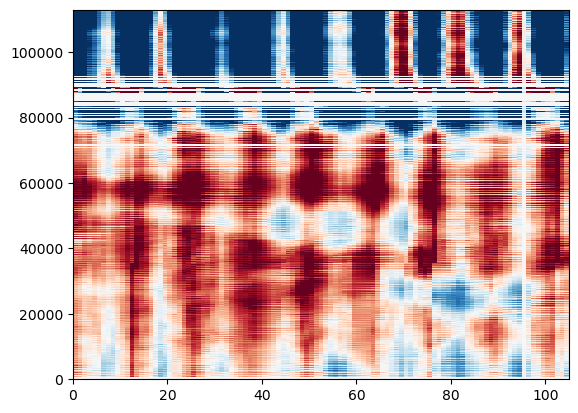

<xarray.DataArray 'ssha' (z: 113022, cycle_num: 105)> Size: 95MB
dask.array<transpose, shape=(113022, 105), dtype=float64, chunksize=(10000, 14), chunktype=numpy.ndarray>
Coordinates:
  * z           (z) object 904kB MultiIndex
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
    latitude    (z) float64 904kB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 904kB dask.array<chunksize=(10000,), meta=np.ndarray>
    pass_num    int64 8B 21
  * num_lines   (z) int64 904kB 5485 5485 5485 5485 5485 ... 7187 7187 7187 7187
  * num_pixels  (z) int64 904kB 0 1 2 3 4 5 6 7 8 ... 60 61 62 63 64 65 66 67 68

In [9]:
zchunk = 10000
h_stacked = (h_dropped 
             - h_dropped.mean(['num_lines','num_pixels'],skipna=True)
            ).stack(z=('num_lines','num_pixels')
                          ).chunk({'z':zchunk}).fillna(0.)
# h_stacked = h_interp.stack(z=("YC", "XC")
#                           ).chunk({'z':zchunk}).fillna(0.)

fig, ax = plt.subplots()
ax.pcolormesh(h_stacked.T.values, 
              rasterized=True,  
              vmax=.4, vmin=-.4, cmap='RdBu_r')
plt.show()
h_stacked.T

In [10]:
nh = 24.*3600.
window_lengths = np.ceil( np.array([12, 13, 30, 60])
                         * 86400/nh ).astype(int) # 24 hourly
step_sizes = np.array([1, 1, 1, 1])
print(window_lengths, "[days]")
nh / 86400.

[12 13 30 60] [days]


1.0

In [11]:
fit = False

In [ ]:
svd_ranks = [4, 4, 10, 12]
if len(svd_ranks) != len(window_lengths):
    print("######### WRONG LENGTHS #########")
suppress_growth = True
transform_method = "absolute"
# n_components_array = [2] * len(window_lengths)
global_svd_array = [False] * len(window_lengths)
# kern_method = "flat"
# real_eig_limit = 0.5
# pydmd_kwargs = {
#     "eig_constraints": {"conjugate_pairs", "limited"},
#     "real_eig_limit": real_eig_limit,
# }

dmd = mrCOSTS(
    svd_rank_array=svd_ranks,
    window_length_array=window_lengths,
    step_size_array=step_sizes,
    global_svd_array=global_svd_array,
    cluster_sweep=True,
    transform_method=transform_method,
    # kern_method=kern_method,
    # relative_filter_length=relative_filter_length,
    # pydmd_kwargs=pydmd_kwargs,
)

if fit:
    dmd.fit(h_stacked.values.T, 
            np.atleast_2d(np.arange(len(h_stacked.cycle_num)
                                   ) * nh)
           )

_________________________________________________
Fitting window length = 9
0 of 97


In [12]:
if fit:
    # dmd.to_netcdf(op.join(ddir, 
    #                       "SWOT/CalVal/mrCOSTS_h/%02dhourly/%02d_fit"
    #                       % (nh,len(window_lengths))
    #                      )
    #              )
    dmd.to_netcdf(ddir + "tssh_swot1day/mrCOSTS/" + 
                  reg +
                  op.join("/Pass%03d_%02d_raw_%02dpoints"
                  % (ipass,len(window_lengths),2)
                         )
                 )
else:
    mrc = glob.glob(ddir + "tssh_swot1day/mrCOSTS/" + 
                    reg +
                    op.join("/Pass%03d_%02d_total*.nc"
                            % (ipass,len(window_lengths))
                           )
                   )
    print(mrc)
    dmd = mrCOSTS()
    dmd.from_netcdf(mrc)

['/storage/tartar/takaya/swot/tssh_swot1day/mrCOSTS/PS/Pass021_04_total.window=15.nc', '/storage/tartar/takaya/swot/tssh_swot1day/mrCOSTS/PS/Pass021_04_total.window=20.nc', '/storage/tartar/takaya/swot/tssh_swot1day/mrCOSTS/PS/Pass021_04_total.window=30.nc', '/storage/tartar/takaya/swot/tssh_swot1day/mrCOSTS/PS/Pass021_04_total.window=60.nc']


In [13]:
dmd.multi_res_interp()
dmd._da_omega

<xarray.DataArray 'omega' (window_length: 4, window_time_means: 91, svd_rank: 12)> Size: 70kB
array([[[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        ...,
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj]],

       [[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
...
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj]],

       [[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        ...,
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj,
         nan+nanj]]], shape=(4, 91, 12))
Coordinates:
  * window_length        (window_length) int64 32B 15 20 30 60
  * window_time_means    (window_time_means) float64 728B 6.048e+05 ... 8.381...
  * svd_rank             (svd_rank) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    slide                (window_length, window_time_means) float64 3kB nan ....
    decomposition_level  (window_length) int64 32B 0 1 2 3

fitting n_components = 4
fitting n_components = 5
fitting n_components = 6
fitting n_components = 7
fitting n_components = 8
fitting n_components = 9
fitting n_components = 10
fitting n_components = 11
fitting n_components = 12
fitting n_components = 13
fitting n_components = 14
fitting n_components = 15
fitting n_components = 16
fitting n_components = 17
fitting n_components = 18
fitting n_components = 19
fitting n_components = 20
fitting n_components = 21
fitting n_components = 22
fitting n_components = 23
fitting n_components = 24
fitting n_components = 25
fitting n_components = 26
fitting n_components = 27
fitting n_components = 28
fitting n_components = 29
Optimal silhouette score is = 5


Text(0, 0.5, 'Silhouette score (-), (1 is best, -1 is worst)')

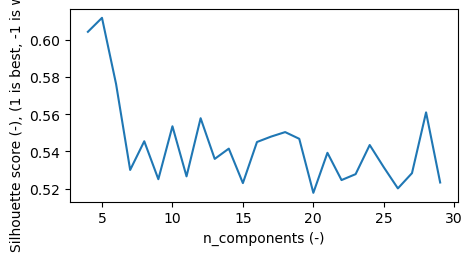

In [14]:
n_components_range = np.arange(4, 30)
scores, n_optimal = dmd.global_cluster_hyperparameter_sweep(
    n_components_range,
    transform_method="log10",
)

print("Optimal silhouette score is = {}".format(n_optimal))
plt.figure(figsize=(5, 2.5))
plt.plot(n_components_range, scores)
plt.gca().set_xlabel("n_components (-)")
plt.gca().set_ylabel("Silhouette score (-), (1 is best, -1 is worst)")

In [15]:
# n_ops = 10
cluster_centroids, omega_classes, omega_array = dmd.global_cluster_omega(
    n_optimal,
    # n_ops,
    transform_method="log10"
)
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi))

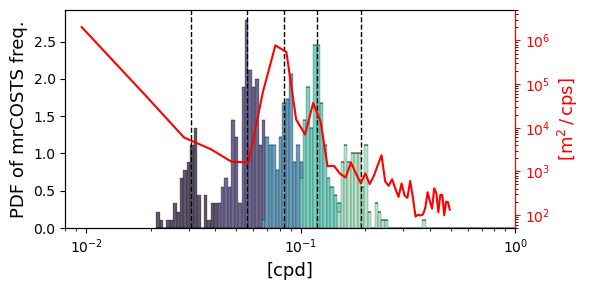

In [16]:
x_trans = (2 * np.pi / 10**omega_array / 86400.)**-1

hue_order = np.arange(len(np.unique(omega_classes))).astype(str)
cluster_centers = 1 / ((10 ** cluster_centroids) / (2 * np.pi) / 86400.)

# Make a continuous color palette with the brightest and darkest excluded
palette = sns.color_palette("mako", len(cluster_centers) + 2)
# palette = palette[1:-1]


Fh = xrft.power_spectrum(h_dropped[...,::150,10::40
                         ].chunk({'cycle_num':-1}
                                ).assign_coords({'cycle_num':
                                                 np.arange(len(h_dropped.cycle_num)) 
                                                 * nh}
                                               ), 
                         dim='cycle_num', window='hann', window_correction=True
                        ).astype(np.single)

from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(6, 3))
ax2 = ax.twinx()
fig.set_tight_layout(True)

ax2.plot(Fh.freq_cycle_num.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                               )*86400, 
         Fh.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                ).mean(['num_pixels','num_lines'],skipna=True)*2,
         c='r', label=r"Fourier")

ax.set_xscale("log")
ax2.set_yscale("log")

sns.histplot(
    # x=((10**omega_array) / (2 * np.pi) / 86400.),
    x=x_trans,
    hue=omega_classes,
    hue_order=hue_order,
    common_bins=True,
    common_norm=True,
    stat="density",
    multiple="stack",
    bins=180,
    palette=ListedColormap(palette),
    legend=False,
    ax=ax
)

ax.set_xlabel(r"[cpd]", fontsize=13)
ax.set_ylabel("PDF of mrCOSTS freq.", fontsize=13)
ax2.set_ylabel("[m$^2\,/\,$cps]", fontsize=13, c='r')

ax.set_xlim([8e-3,1e0])
# ax2.set_xlim([8e-3,1.5e1])
ax2.set_ylim([5e1,5e6])

ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')

[
    ax.axvline((2 * np.pi / (10**c) / 86400)**-1, color="k", ls="--", lw=1)
    for nc, c in enumerate(cluster_centroids)
];

# plt.savefig(op.join(ddir,'../Figs/SWOT_Pass%03d-detided_mrCOSTS_hist-%02d.pdf' 
#                     % (ipass,len(window_lengths)))
#            )

In [17]:
np.where((2 * np.pi / (10**cluster_centroids) 
          / 86400)**-1 <= 14**-1)

(array([0, 1]),)

In [18]:
omega_classes_list = dmd.multi_res_deterp()

In [19]:
xr_background = dmd.get_background()
print(xr_background.shape, h_stacked)

ds_global_background = xr.DataArray(xr_background, dims=h_stacked.T.dims,
                            coords=h_stacked.T.coords
                           ).unstack().chunk({'cycle_num':1}
                                            ).interp(
                        num_pixels=mm21.drop("cycle_num").num_pixels,
                        num_lines=mm21.drop("cycle_num").num_lines
                                               ).where(mm21!=1
                                                      )

ds_global_background.chunk(
        {'num_pixels':-1, 'num_lines':-1}
).to_dataset(name='background'
            ).to_zarr(op.join(ddir,
            'tssh_swot1day/Pass%03d/%2s/background-total.zarr' 
                              % (ipass, reg)),
                              mode='w')

(113022, 105) <xarray.DataArray 'ssha' (cycle_num: 105, z: 113022)> Size: 95MB
dask.array<where, shape=(105, 113022), dtype=float64, chunksize=(14, 10000), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * z           (z) object 904kB MultiIndex
    latitude    (z) float64 904kB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 904kB dask.array<chunksize=(10000,), meta=np.ndarray>
    pass_num    int64 8B 21
  * num_lines   (z) int64 904kB 5485 5485 5485 5485 5485 ... 7187 7187 7187 7187
  * num_pixels  (z) int64 904kB 0 1 2 3 4 5 6 7 8 ... 60 61 62 63 64 65 66 67 68


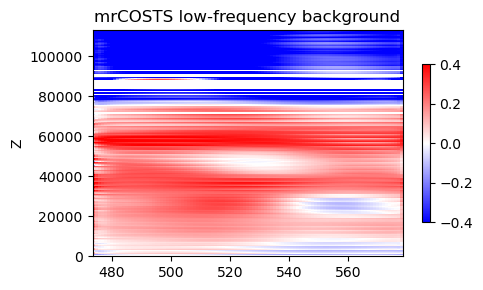

In [20]:
fig, ax = plt.subplots(figsize=(5, 3))
fig.set_tight_layout(True)
im = ax.pcolormesh(
    h_stacked.cycle_num,
    np.arange(len(h_stacked.z)), 
    xr_background, 
    vmin=-.4, vmax=.4, cmap="bwr",
    rasterized=True
)
ax.set_title("mrCOSTS low-frequency background")
ax.set_ylabel("Z")
# fig.autofmt_xdate()
fig.colorbar(im, shrink=.7)

In [21]:
xr_sep = dmd.global_scale_reconstruction()

In [22]:
for ncl_center, cl_center in enumerate(cluster_centers_periods):
    
    ds_xr_sep = xr.DataArray(
        xr_sep.real[:, ncl_center],
        dims=["decomp_level", "z", "cycle_num"],
        coords=[
            np.arange(len(dmd.costs_array)),
            # np.arange(n_optimal),
            h_stacked.z,
            h_stacked.cycle_num,
        ],
    )
    
    for dd in ds_xr_sep.decomp_level:
        if dd == 0:
            sep_unstacked = ds_xr_sep.sel(decomp_level=dd
                                 ).unstack().chunk({'cycle_num':1})
        else:
            tmp = ds_xr_sep.sel(decomp_level=dd
                               ).unstack().chunk({'cycle_num':1})
            sep_unstacked = xr.concat([sep_unstacked,
                                       tmp
                                      ], 'decomp_level'
                                     )
            del tmp

    ds_global_separation = sep_unstacked.interp(
                        num_pixels=mm21.drop("cycle_num").num_pixels,
                        num_lines=mm21.drop("cycle_num").num_lines
                                               ).where(mm21!=1
                                                      )

    ds_cluster_centers = xr.DataArray(
        np.array([1 / (10 ** (cluster_centroids[ncl_center]) / (2 * np.pi)),]),
        dims=["cluster"],
        # coords=[np.arange(n_optimal)],
        coords=[np.array([ncl_center,])],
    )
    ds_cluster_centers.attrs["units"] = "s"
    ds_cluster_centers.attrs["long_name"] = "Central period of each period band"
    
    ds_global_separation = ds_global_separation.to_dataset(name="frequency_bands")
    ds_global_separation["frequency_bands"].attrs["units"] = "m"
    ds_global_separation["frequency_bands"].attrs["long_name"] = "mrCOSTS"
    
    ds_global_separation.coords["cluster_centers"] = ds_cluster_centers

    if ncl_center == 0:
        print(ds_global_separation)
        
    ds_global_separation.chunk(
                {'num_pixels':-1, 'num_lines':-1}
                ).to_zarr(op.join(ddir,
    'tssh_swot1day/Pass%03d/%2s/cluster%02d-total.zarr' 
                      % (ipass, reg, ncl_center)),
                      mode='w')
    print(ncl_center)

<xarray.Dataset> Size: 397MB
Dimensions:          (decomp_level: 4, cycle_num: 105, num_pixels: 69,
                      num_lines: 1703, cluster: 1)
Coordinates:
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_pixels       (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 63 64 65 66 67 68
  * num_lines        (num_lines) int64 14kB 5485 5486 5487 ... 7185 7186 7187
  * cluster          (cluster) int64 8B 0
    pass_num         int64 8B 21
    latitude         (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    longitude        (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    cluster_centers  (cluster) float64 8B 2.813e+06
Data variables:
    frequency_bands  (decomp_level, cycle_num, num_lines, num_pixels) float64 395MB dask.array<chunksize=(1, 1, 1703, 69), meta=np.ndarray>
0
1
2
3
4


In [25]:
xr_global_reconstruction = dmd.global_reconstruction()
glb_unstacked = xr.DataArray(
    data=xr_global_reconstruction.real, 
    dims=h_stacked.T.dims,
    coords=h_stacked.T.coords
).unstack()

da_global_reconstruction = glb_unstacked.interp(
                        num_pixels=mm21.drop("cycle_num").num_pixels,
                        num_lines=mm21.drop("cycle_num").num_lines
                                               ).where(mm21!=1
                                                      )
da_global_reconstruction.attrs["units"] = "m"
da_global_reconstruction.attrs["long_name"] = r"SWOT SSH"

da_global_reconstruction.chunk(
    # {'lat':100, 'lon':100}
).to_dataset(name='SSH').to_zarr(op.join(ddir,
                    'tssh_swot1day/Pass%03d/%2s/Total-total.zarr' 
                      % (ipass, reg)),
                      mode='w')

# Extract the slow component

In [23]:
for i in range(30):
    if i == 0:
        dsc = xr.open_zarr(op.join(ddir,
            'tssh_swot1day/Pass%03d/%2s/cluster%02d-total.zarr' 
                                    % (ipass,reg,i))
                           )

    else:
        try:
            dsc = xr.concat([dsc,xr.open_zarr(op.join(ddir,
                    'tssh_swot1day/Pass%03d/%2s/cluster%02d-total.zarr' 
                                  % (ipass,reg,i)))
                            ], 'cluster')

        except:
            pass
    
# dsC = xr.open_zarr(op.join(ddir,
#             'tssh_swot1day/Pass%03d/%2s/Total-total.zarr' 
#                            % (ipass,reg))
#                   )

dsb = xr.open_zarr(op.join(ddir,
            'tssh_swot1day/Pass%03d/%2s/background-total.zarr' 
                           % (ipass,reg))
                  )

dsc

<xarray.Dataset> Size: 2GB
Dimensions:          (cluster: 5, decomp_level: 4, cycle_num: 105,
                      num_lines: 1703, num_pixels: 69)
Coordinates:
  * cluster          (cluster) int64 40B 0 1 2 3 4
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_lines        (num_lines) int64 14kB 5485 5486 5487 ... 7185 7186 7187
  * num_pixels       (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 63 64 65 66 67 68
    cluster_centers  (cluster) float64 40B dask.array<chunksize=(1,), meta=np.ndarray>
    latitude         (num_lines, num_pixels) float64 940kB 10.01 10.01 ... 39.99
    longitude        (num_lines, num_pixels) float64 940kB 126.2 126.2 ... 133.8
    pass_num         int64 8B 21
Data variables:
    frequency_bands  (cluster, decomp_level, cycle_num, num_lines, num_pixels) float64 2GB dask.array<chunksize=(1, 1, 1, 1703, 69), meta=np.ndarray>

In [24]:
try:
    low = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-total.zarr" 
                               % (ipass,reg))
                      ).ssha
except:
    n_cluster = len(np.where((2 * np.pi / (10**cluster_centroids) 
                              / 86400.)**-1 <= 14**-1)[0]
                   )
    print(n_cluster)
    low = ((dsb.background 
            + dsc.frequency_bands.isel(cluster=slice(None,n_cluster)
                                      ).sum(['cluster','decomp_level'])
           )
           # + h_dropped.mean(['num_lines','num_pixels'],skipna=True)
          )
    low.to_dataset(name="ssha").to_zarr(op.join(ddir,
                                                "tssh_swot1day/geos/Pass%03d/%2s/SSHa-total.zarr" 
                                                % (ipass,reg)),
                                        mode="w")

# tot = xr.open_zarr(op.join(ddir,
#                    'tssh_swot1day/Pass%03d/%2s/Total-total.zarr' 
#                    % (ipass,reg))
#                   ).SSH
low

2


<xarray.DataArray (cycle_num: 105, num_lines: 1703, num_pixels: 69)> Size: 99MB
dask.array<add, shape=(105, 1703, 69), dtype=float64, chunksize=(1, 1703, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 5485 5486 5487 5488 ... 7185 7186 7187
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    pass_num    int64 8B 21
    latitude    (num_lines, num_pixels) float64 940kB 10.01 10.01 ... 40.0 39.99
    longitude   (num_lines, num_pixels) float64 940kB 126.2 126.2 ... 133.8

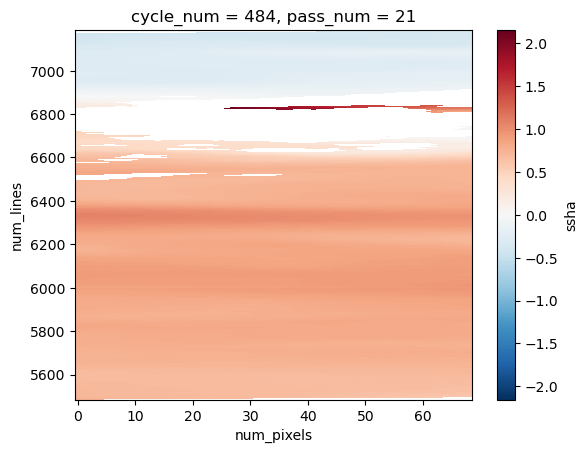

In [49]:
low.isel(cycle_num=10).plot(rasterized=True)

# Compute geostrophy

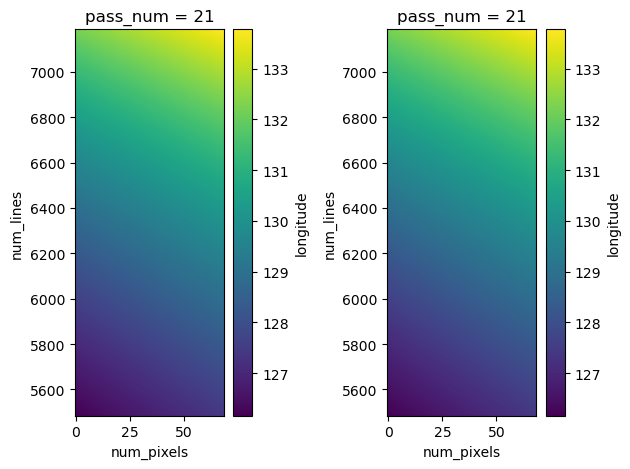

In [50]:
lati = low.latitude
longi = low.longitude
if (longi.max(skipna=True)-longi.min(skipna=True)) > 180.:
    print("Recasting longitude.")
    # long[long>180.] -=-360
    # long_values = long.values
    # long_values[long_values > 180.] -= 360.
    # long_adjusted = long.copy(data=long_values
    #                          ).where(mm01.isel(num_pixels=slice(1,-1), num_lines=slice(1,-1)
    #                                           )!=1, drop=True
    #                                 )
    # long_masked = xr.where(long > 180, long - 360, long)
    long_adjusted = xr.where(longi > 180, longi - 360, longi)
else:
    # long_masked = long.copy()
    long_adjusted = longi

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)
longi.plot(ax=ax1)
long_adjusted.plot(ax=ax2)
# long_masked.plot(ax=ax3)

In [ ]:
import sys
sys.path.append('../../')
from SwotDiag.diagnosis import *

params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 5, # 5x5 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          cyclostrophy = 'GW', # Cyclogeostrophic currents are computed using the wind-gradient balance
          avoid_negative = True, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          second_derivative = 'dxdy', # The second derivative is obtained by point-difference the first derivative (obtained by surface fitting method), rather than from the surface curvature. I noticed that it reduces the noise. 
          kernel = 'circular', # can be circular or a square, the shape of the kernel

)

## Diagnostics from original SSH
for cc in low.cycle_num:
    diag = compute_ocean_diagnostics_from_eta(low.sel(cycle_num=cc), 
                                          low.longitude, low.latitude, **params
                                             )
    if cc == low.cycle_num[0]:
        dsave = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name="ug")
        dsave["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
    else:
        tmp = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name="ug")
        tmp["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave = xr.concat([dsave, tmp], "cycle_num")
        del tmp

print(dsave)

dsave.chunk({"cycle_num":1}).to_zarr(op.join(ddir,
                                        "tssh_swot1day/geos/Pass%03d/%2s/SSVs-total_SwotDiag.zarr" 
                                          % (ipass,reg)),
                                  mode="w")

TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library n

In [7]:
import sys
sys.path.append('../')
from SwotDiag.diagnosis import *

params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 5, # 5x5 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          cyclostrophy = 'GW', # Cyclogeostrophic currents are computed using the wind-gradient balance
          avoid_negative = True, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          second_derivative = 'dxdy', # The second derivative is obtained by point-difference the first derivative (obtained by surface fitting method), rather than from the surface curvature. I noticed that it reduces the noise. 
          kernel = 'circular', # can be circular or a square, the shape of the kernel

)

## Diagnostics from original SSH
for cc in ds04.cycle_num:
    diag = compute_ocean_diagnostics_from_eta(ds04.ssha_detided.sel(cycle_num=cc) * 1e-2, 
                                          ds04.longitude, ds04.latitude, **params
                                             )
    if cc == ds04.cycle_num[0]:
        dsave = xr.DataArray(diag["ug"], dims=ds04.sel(cycle_num=cc).dims,
                             coords=ds04.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        dsave["vg"] = xr.DataArray(diag["vg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        dsave["ucg"] = xr.DataArray(diag["ucg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        dsave["vcg"] = xr.DataArray(diag["vcg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        dsave["vort"] = xr.DataArray(diag["zeta"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        dsave["strain"] = xr.DataArray(diag["S"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
    else:
        tmp = xr.DataArray(diag["ug"], dims=ds04.sel(cycle_num=cc).dims,
                             coords=ds04.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        tmp["vg"] = xr.DataArray(diag["vg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        tmp["ucg"] = xr.DataArray(diag["ucg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        tmp["vcg"] = xr.DataArray(diag["vcg"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        tmp["vort"] = xr.DataArray(diag["zeta"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        tmp["strain"] = xr.DataArray(diag["S"], dims=ds04.sel(cycle_num=cc).dims,
                                 coords=ds04.sel(cycle_num=cc).coords
                                )
        dsave = xr.concat([dsave, tmp], "cycle_num")
        del tmp

dsave.coords["cycle_num"] = ds04.cycle_num
print(dsave)

dsave.chunk({"cycle_num":1}).to_zarr(op.join(ddir,
                                             "CalVal/geos/Pass%03d/SSVs_rawSwotDiag.zarr" 
                                          % ipass),
                                  mode="w")

TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library n

In [15]:
dsh = xr.open_dataset(op.join(ddir,"HYCOM-tidal-correction/hycom_ssh_pass%02d_swot1day_v2.0.1.nc"
                              % ipass)
                     )
dsh

<xarray.Dataset> Size: 2GB
Dimensions:      (num_cycle: 105, num_pass: 1, num_lines: 9860, num_pixels: 69)
Coordinates:
  * num_cycle    (num_cycle) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_pass     (num_pass) int64 8B 4
  * num_lines    (num_lines) int64 79kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels   (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude     (num_lines, num_pixels) float64 5MB ...
    longitude    (num_lines, num_pixels) float64 5MB ...
Data variables:
    hycom_coh    (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
    hycom_incoh  (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
    hycom_total  (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
Attributes:
    description:  Phase-locked and Non-phase-locked internal tides from HYCOM...
    created_by:   B. Yadidya
    created_on:   Oct 28, 2025 12:39

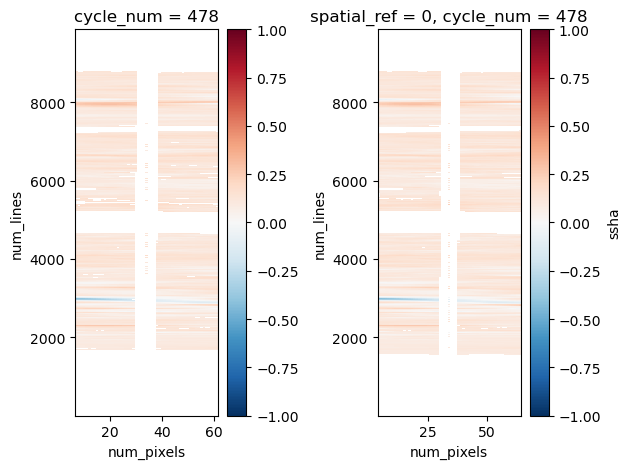

In [16]:
ageo = (1e-2*ds04.ssha_detided
        - low
       )
ic = 0
for cc in ageo.cycle_num:
    
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r04 = xr.concat([r04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref:
        if ic == 0:
            a04 = ssha
        else:
            try:
                a04 = xr.concat([a04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a04.coords["cycle_num"] = ("cycle_num",
                           r04.where(r04>0.7*r_ref, drop=True).cycle_num.data
                          )

dsa04 = a04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha

a04_exterp = _a04_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds04.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)

ageo.sel(cycle_num=478).isel(num_pixels=slice(inp,-inp)
                            ).plot(ax=ax1, rasterized=True, vmax=1e0)
a04_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e0)

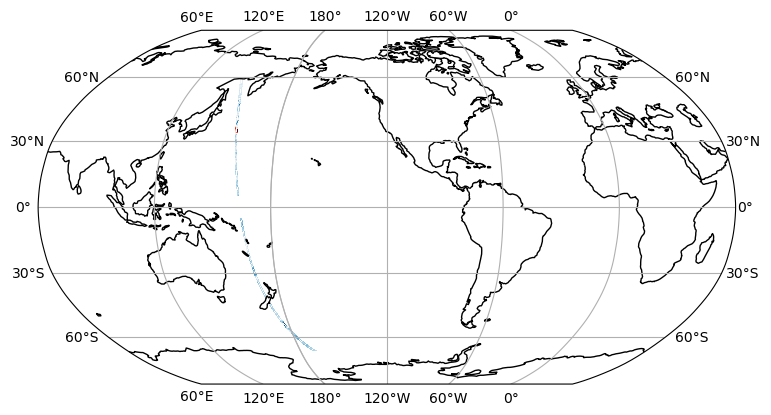

In [22]:
import cartopy.crs as ccrs
import cartopy.util as cutil

fig = plt.figure(figsize=(9,5))

# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.Robinson(central_longitude=240)
                    )
ax.set_global()
ax.pcolormesh(long_adjusted, a04_exterp.latitude, a04_exterp.isel(cycle_num=1),
          transform=ccrs.PlateCarree(), 
              cmap='RdBu',
          vmin=-.4, vmax=.4,
          rasterized=True)
ax.coastlines()
ax.gridlines(draw_labels=True)

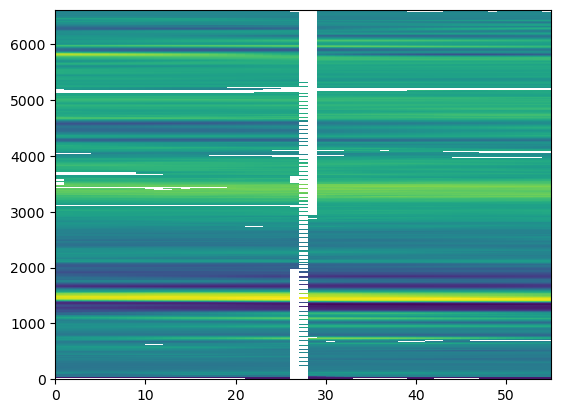

(<xarray.DataArray 'ssha' (cycle_num: 96, num_lines: 9310, num_pixels: 61)> Size: 436MB
 dask.array<mul, shape=(96, 9310, 61), dtype=float64, chunksize=(96, 776, 7), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 768B 483 484 485 486 487 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>,
 <xarray.DataArray 'ssha' (cycle_num: 96, num_lines: 6621, num_pixels: 55)> Size: 280MB
 dask.array<where, shape=(96, 6621, 55), dtype=float64, chunksize=(96, 775, 6), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 768B 483 484 485 486 487 ... 575 576 577 578
   * num_lines   (num_lines) int64 53kB 1545 1548 1549 1550

In [26]:
nd = 10
fscale = 3
h_interp = xr.open_zarr(op.join(ddir,
                        'CalVal/%02dD_rolling/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                        % (nd,ipass,fscale))
                       ).ssha.interp(cycle_num=ds04.cycle_num.isel(cycle_num=slice(nd-1,None)), 
                                     method="slinear",
                                     kwargs={"fill_value": "extrapolate"}
                                    ) * 1e-2   # centimeters to meters

low = h_interp.where(mm04.isel(num_pixels=slice(1,-1),
                               num_lines=slice(1,-1)
                              ).reset_coords(drop=True)!=1)
h_dropped = h_interp.where(mm04.isel(num_pixels=slice(1,-1),
                               num_lines=slice(1,-1)
                              ).reset_coords(drop=True)!=1, drop=True)

plt.pcolormesh(h_dropped.isel(cycle_num=10).data,rasterized=True)
plt.show()
h_interp, h_dropped, low

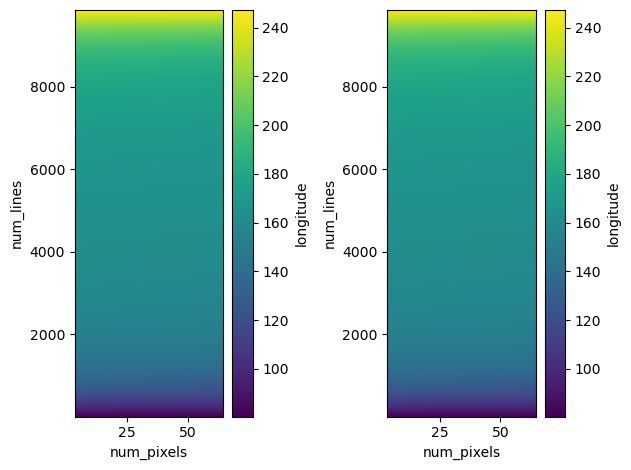

In [27]:
lati = low.latitude
longi = low.longitude
if (longi.max(skipna=True)-longi.min(skipna=True)) > 180.:
    print("Recasting longitude.")
    # long[long>180.] -=-360
    # long_values = long.values
    # long_values[long_values > 180.] -= 360.
    # long_adjusted = long.copy(data=long_values
    #                          ).where(mm01.isel(num_pixels=slice(1,-1), num_lines=slice(1,-1)
    #                                           )!=1, drop=True
    #                                 )
    # long_masked = xr.where(long > 180, long - 360, long)
    long_adjusted = xr.where(longi > 180, longi - 360, longi)
else:
    # long_masked = long.copy()
    long_adjusted = longi

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)
longi.plot(ax=ax1)
long_adjusted.plot(ax=ax2)
# long_masked.plot(ax=ax3)

In [53]:
import sys
sys.path.append('../../')
from SwotDiag.diagnosis import *

params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 5, # 5x5 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          cyclostrophy = 'GW', # Cyclogeostrophic currents are computed using the wind-gradient balance
          avoid_negative = True, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          second_derivative = 'dxdy', # The second derivative is obtained by point-difference the first derivative (obtained by surface fitting method), rather than from the surface curvature. I noticed that it reduces the noise. 
          kernel = 'circular', # can be circular or a square, the shape of the kernel

)

## Diagnostics from original SSH
for cc in low.cycle_num:
    diag = compute_ocean_diagnostics_from_eta(low.sel(cycle_num=cc), 
                                          low.longitude, low.latitude, **params
                                             )
    if cc == low.cycle_num[0]:
        dsave = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        dsave["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
    else:
        tmp = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        tmp["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave = xr.concat([dsave, tmp], "cycle_num")
        del tmp

print(dsave)

dsave.chunk({"cycle_num":1}).to_zarr(op.join(ddir,
                                 "CalVal/geos/%02dD_rolling/Pass%03d/SSVs_SwotDiag.zarr" 
                                          % (nd,ipass)),
                                  mode="w")

TQDM library not available. Running without progress bar.


KeyboardInterrupt: 